In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


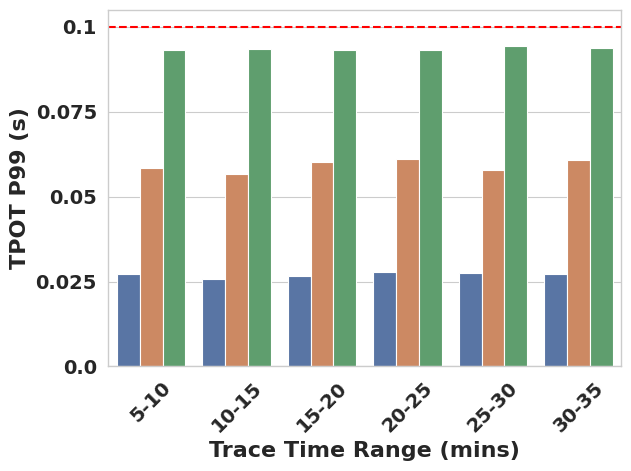

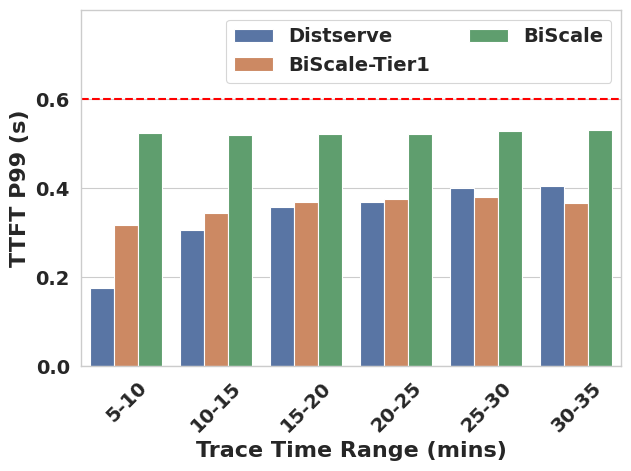

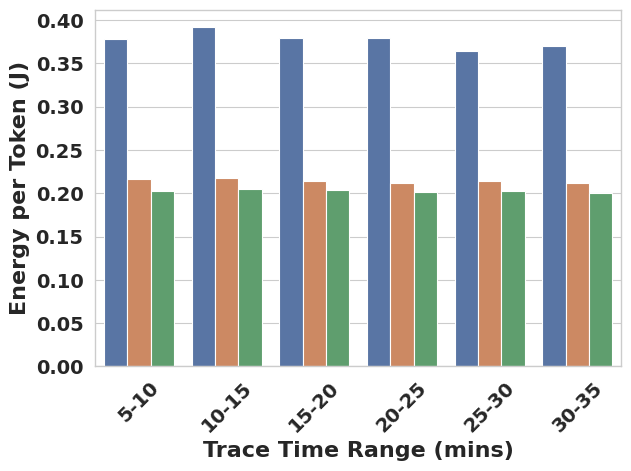

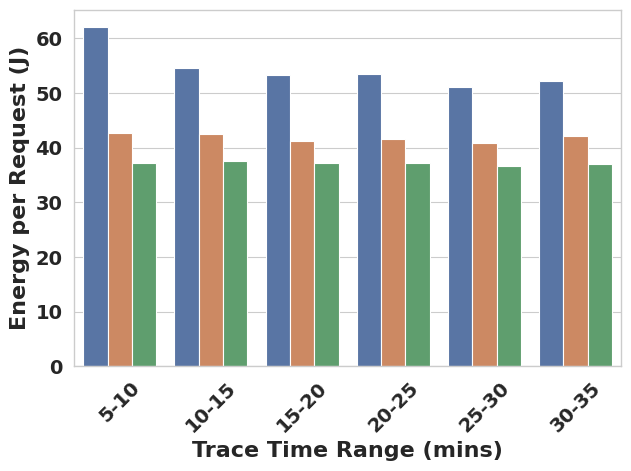

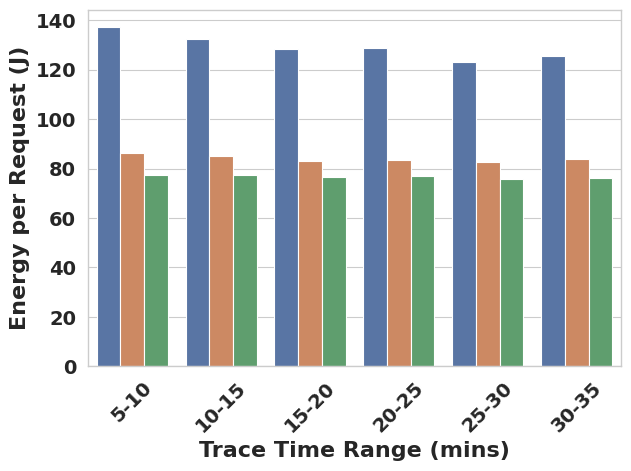

In [4]:
path_disag = "/export5/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/oracle_67_percent/profiler_logs_0_March29_oracle_fix/chunked/metrics.csv"
df_results_disag = pd.read_csv(path_disag)

path_coll = "/export5/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/oracle_67_percent/profiler_logs_0_March29_oracle_fix/disag/metrics.csv"
df_results_coll = pd.read_csv(path_coll)

df_results = pd.concat([df_results_disag, df_results_coll], ignore_index=True)

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_R5_JAN3_REAL_P67_ORACLE_7_node0': 'Distserve 85',
    'DISTSERVE_R5_JAN3_REAL_P67_ORACLE_6_node0': 'Distserve 70',
    'DISTSERVE_R5_JAN3_REAL_P67_ORACLE_5_node0': 'Distserve 55',
    'DISTSERVE_R5_JAN3_REAL_P67_ORACLE_4_node0': 'Distserve 40',
    'DISTSERVE_R5_JAN3_REAL_P67_ORACLE_3_node0': 'Distserve 25',
    'DISTSERVE_R5_JAN3_REAL_P67_ORACLE_2_node0': 'Distserve 10',
    'OURS_R5_JAN3_REAL_P67_ORACLE_7_node0': 'BiScale-Tier1 85',
    'OURS_R5_JAN3_REAL_P67_ORACLE_6_node0': 'BiScale-Tier1 70',
    'OURS_R5_JAN3_REAL_P67_ORACLE_5_node0': 'BiScale-Tier1 55',
    'OURS_R5_JAN3_REAL_P67_ORACLE_4_node0': 'BiScale-Tier1 40',
    'OURS_R5_JAN3_REAL_P67_ORACLE_3_node0': 'BiScale-Tier1 25',
    'OURS_R5_JAN3_REAL_P67_ORACLE_2_node0': 'BiScale-Tier1 10',
    'OURS_R5_JAN3_REAL_P67_ORACLE_7_DVFS_node0': 'BiScale 85',
    'OURS_R5_JAN3_REAL_P67_ORACLE_6_DVFS_node0': 'BiScale 70',
    'OURS_R5_JAN3_REAL_P67_ORACLE_5_DVFS_node0': 'BiScale 55',
    'OURS_R5_JAN3_REAL_P67_ORACLE_4_DVFS_node0': 'BiScale 40',
    'OURS_R5_JAN3_REAL_P67_ORACLE_3_DVFS_node0': 'BiScale 25',
    'OURS_R5_JAN3_REAL_P67_ORACLE_2_DVFS_node0': 'BiScale 10',

}

# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)

df_results = df_results[df_results["instance"] == "total"]

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
# df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'BiScale-Tier1', 'BiScale', 'Collocated-Tier1', 'Collocated'], ordered=True)
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'BiScale-Tier1', 'BiScale'], ordered=True)
df_results = df_results.sort_values(['rps', 'name'])

#################### TPOT P99 ####################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.1, color='red', linestyle='--', linewidth=1.5)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('TPOT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.105)
ax.set_xticks([1, 2, 3, 4, 5, 6])
ax.set_xlim(0.5, 6.5)
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.set_yticks([0.0, 0.025, 0.05, 0.075, 0.1])
ax.set_yticklabels(['0.0', '0.025', '0.05', '0.075', '0.1'], fontsize=14, fontweight='bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/p67_oracle_tpot.pdf", format="pdf")

#################### TTFT P99 ####################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="ttft_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('TTFT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.8)
ax.set_xticks([1, 2, 3, 4, 5, 6])
ax.set_xlim(0.5, 6.5)
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.set_yticks([0.0, 0.2, 0.4, 0.6])
ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6'], fontsize=14, fontweight='bold')
ax.legend(title="", ncol=2, prop={"size": 14, "weight": "bold"})
plt.tight_layout()
plt.savefig("figs/p67_oracle_ttft.pdf", format="pdf")

#################### Energy per token - decode ####################
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="decode_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Token (J)', fontsize=16, fontweight='bold')
ax.set_xticks([1, 2, 3, 4, 5, 6])
ax.set_xlim(0.5, 6.5)
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/p67_oracle_energy_per_token_decode.pdf", format="pdf")

#################### Energy per token - prefill ####################
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="prefill_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Request (J)', fontsize=16, fontweight='bold')
ax.set_xticks([1, 2, 3, 4, 5, 6])
ax.set_xlim(0.5, 6.5)
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/p67_oracle_energy_per_request_prefill.pdf", format="pdf")

#################### Energy per token - total ####################
df_results['energy_per_req'] = df_results['energy_j'] / df_results['num_requests']
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="energy_per_req", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Request (J)', fontsize=16, fontweight='bold')
ax.set_xticks([1, 2, 3, 4, 5, 6])
ax.set_xlim(0.5, 6.5)
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/p67_oracle_energy_per_request_total.pdf", format="pdf")

In [5]:
df_results = df_results[df_results["name"].isin(["Distserve", "BiScale-Tier1", "BiScale"])].copy()

# Normalize energy with Distserve energy for both prefill and decode
df_results['energy_norm_prefi_D'] = df_results.apply(
    lambda row: (1 - row['prefill_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['prefill_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_deco_D'] = df_results.apply(
    lambda row: (1 - row['decode_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['decode_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_prefi_M'] = df_results.apply(
    lambda row: (1 - row['prefill_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'BiScale-Tier1')
    ]['prefill_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_deco_M'] = df_results.apply(
    lambda row: (1 - row['decode_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'BiScale-Tier1')
    ]['decode_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_D'] = df_results.apply(
    lambda row: (1 - row['energy_per_req'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['energy_per_req'].values[0]) * 100,
    axis=1
)
df_results['energy_share_prefill'] = df_results['energy_prefill'] / (df_results['energy_j']) * 100
df_results['energy_share_decode'] = df_results['energy_decode'] / (df_results['energy_j']) * 100
df_results[['expr_dir', 'energy_j', 'energy_prefill', 'energy_decode', 'energy_per_token', 'energy_per_req', 'energy_share_prefill', 'energy_share_decode', 'energy_norm_prefi_D', 'energy_norm_deco_D', 'energy_norm_prefi_M', 'energy_norm_deco_M', 'energy_norm_D']].sort_values('expr_dir', ascending=False)

,expr_dir,energy_j,energy_prefill,energy_decode,energy_per_token,energy_per_req,energy_share_prefill,energy_share_decode,energy_norm_prefi_D,energy_norm_deco_D,energy_norm_prefi_M,energy_norm_deco_M,energy_norm_D
96,Distserve 85,2.193475e+06,9.112612e+05,1.282214e+06,0.630230,125.585410,41.544186,58.455814,0.000000,0.000000,-23.858761,-74.492561,0.000000
90,Distserve 70,2.202340e+06,9.155399e+05,1.286800e+06,0.619713,122.960206,41.571227,58.428773,0.000000,0.000000,-25.049201,-69.756589,0.000000
84,Distserve 55,2.168586e+06,8.989822e+05,1.269603e+06,0.645577,128.890676,41.454770,58.545230,0.000000,0.000000,-28.369994,-79.554114,0.000000
78,Distserve 40,2.176295e+06,9.026728e+05,1.273623e+06,0.645626,128.319308,41.477493,58.522507,0.000000,0.000000,-29.160957,-77.224127,0.000000
72,Distserve 25,2.135650e+06,8.792485e+05,1.256401e+06,0.663628,132.353104,41.170070,58.829930,0.000000,0.000000,-28.255549,-80.128217,0.000000
66,Distserve 10,2.320437e+06,1.049222e+06,1.271215e+06,0.686694,137.287717,45.216566,54.783434,0.000000,0.000000,-45.240779,-74.627911,0.000000
180,BiScale-Tier1 85,1.464750e+06,7.356419e+05,7.291081e+05,0.424136,83.872533,50.223034,49.776966,19.262877,42.690967,0.000000,0.000000,33.214747
166,BiScale-Tier1 70,1.480524e+06,7.321437e+05,7.483803e+05,0.421945,82.660042,49.451661,50.548339,20.031476,41.092124,0.000000,0.000000,32.774965
152,BiScale-Tier1 55,1.406354e+06,7.003888e+05,7.059655e+05,0.419326,83.577247,49.801730,50.198270,22.100176,44.306484,0.000000,0.000000,35.156483
138,BiScale-Tier1 40,1.408247e+06,6.989980e+05,7.092493e+05,0.423284,83.018763,49.636026,50.363974,22.577223,43.574274,0.000000,0.000000,35.302984
